In [22]:
# Data handling
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, csc_matrix

# Plotting
import matplotlib.pyplot as plt

# Deep Learning
import torch 
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from anndata.experimental.pytorch import AnnLoader
from anndata.experimental import AnnCollection

# Baseline Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings("ignore")

In [2]:
print(f"Anndata version: {ad.__version__}")
print(f"Pytorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Anndata version: 0.12.10
Pytorch version: 2.10.0+cpu
CUDA available: False


In [ ]:
vasc_path = "Vasculature_cells.h5ad"
# ensure that the file was properly saved
adata = sc.read_h5ad(vasc_path)
print(f"Successfully read and saved {adata.n_obs} cells")

Successfully read and saved 17974 cells


AnnData object with n_obs × n_vars = 17974 × 33538
    obs: 'cell_type_high_resolution', 'subject', 'ident'
    obsm: 'X_umap'
    layers: 'logcounts'

 + cell clusters and batch info:
                     cell_type_high_resolution       subject       ident
GACTACAAGGCTCTTA-1-0                Fib SLC4A4  ROSMAP-52226  Fib SLC4A4
ACTGAGTTCACTTATC-2-0                 Fib FLRT2  ROSMAP-72912   Fib FLRT2
CACAAACGTAAGGGAA-2-0                 Fib FLRT2  ROSMAP-72912   Fib FLRT2
CGGTTAAAGGCTCAGA-2-0                 Fib FLRT2  ROSMAP-72912   Fib FLRT2
TACCTTACATTAACCG-2-0                 Fib FLRT2  ROSMAP-72912   Fib FLRT2

 + metadata cols:
Index(['GACTACAAGGCTCTTA-1-0', 'ACTGAGTTCACTTATC-2-0', 'CACAAACGTAAGGGAA-2-0',
       'CGGTTAAAGGCTCAGA-2-0', 'TACCTTACATTAACCG-2-0', 'ACAGCCGTCAACGGGA-3-0',
       'AGCATACTCGTTGACA-3-0', 'CAGCTAAAGGTAGCCA-3-0', 'CATGCCTCAGCTGCTG-3-0',
       'CGACCTTAGCTGATAA-3-0',
       ...
       'TTCCTTCTCGACGTCG-15-14', 'TTTCGATTCGTTCCTG-15-14',
       'AAACGCTAGTAA

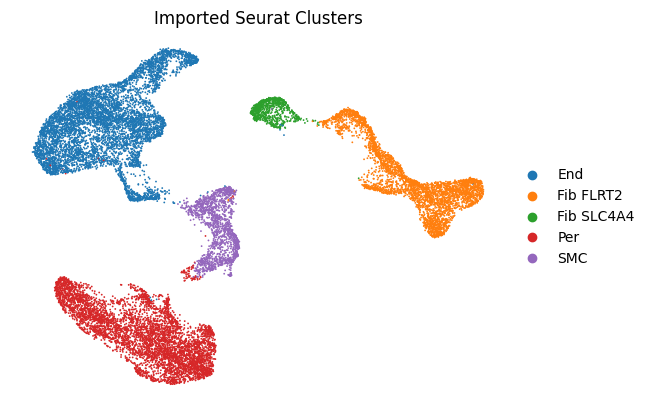

In [4]:
# Show data
print(adata)

# See cell clusters and batch info
print("\n + cell clusters and batch info:")
print(adata.obs.head())

# List all available metadata columns
print("\n + metadata cols:")
print(adata.obs_names)

# This prints all available category names you can use for plotting
print(adata.obs.columns.tolist())

# Check the type and shape
print("\n + type and shape:")
print(type(adata.X))
print(adata.X.shape)

# View a small slice of raw counts (first 5 cells, first 5 genes)
# If it's sparse, you might need to use .toarray() to read it
print("\n + slice of raw counts:")
print(adata.X[:10, :10].toarray())

# See gene names and any HVG (Highly Variable Gene) info
print("\n + gene names, HVG info:")
print(adata.var.head())

# List the names of all available reductions
print("\n + available reductions:")
print(adata.obsm.keys())

# View the actual UMAP coordinates
print("\n + umap coords:")
print(adata.obsm['X_umap'][:5])

# This prints all available category names you can use for plotting
print(adata.obs.columns.tolist())

# Plot UMAP colored by clusters
print("\n + plotting umap:")
sc.pl.umap(adata, color='ident', frameon=False, title="Imported Seurat Clusters")

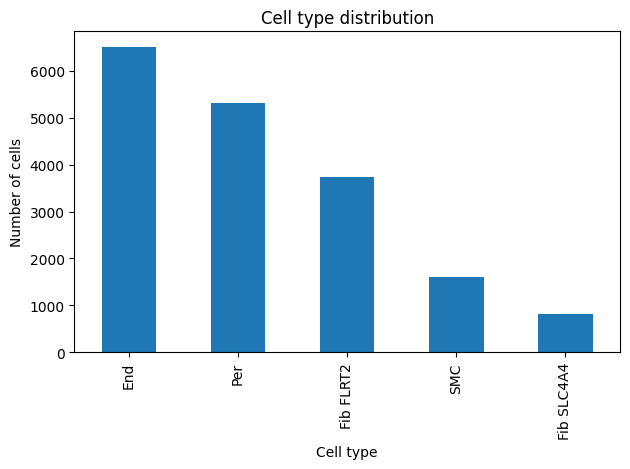

cell_type_high_resolution
End           6514
Per           5308
Fib FLRT2     3728
SMC           1605
Fib SLC4A4     819
Name: count, dtype: int64

In [ ]:
ct_counts = adata.obs["cell_type_high_resolution"].value_counts()
ct_counts.plot(kind="bar")

plt.ylabel("Number of cells")
plt.xlabel("Cell type")
plt.title("Cell type distribution")
plt.tight_layout()
plt.show()

In [39]:
adata.obs

,cell_type_high_resolution,subject,ident
GACTACAAGGCTCTTA-1-0,Fib SLC4A4,ROSMAP-52226,Fib SLC4A4
ACTGAGTTCACTTATC-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
CACAAACGTAAGGGAA-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
CGGTTAAAGGCTCAGA-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
TACCTTACATTAACCG-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
...,...,...,...
CATTCCGAGCGACCCT-16-14,Per,ROSMAP-37074,Per
CGAAGGACAACGAGGT-16-14,Per,ROSMAP-37074,Per
CTAGACAAGCCACCGT-16-14,End,ROSMAP-37074,End
TTACGTTAGTAAACAC-16-14,End,ROSMAP-37074,End


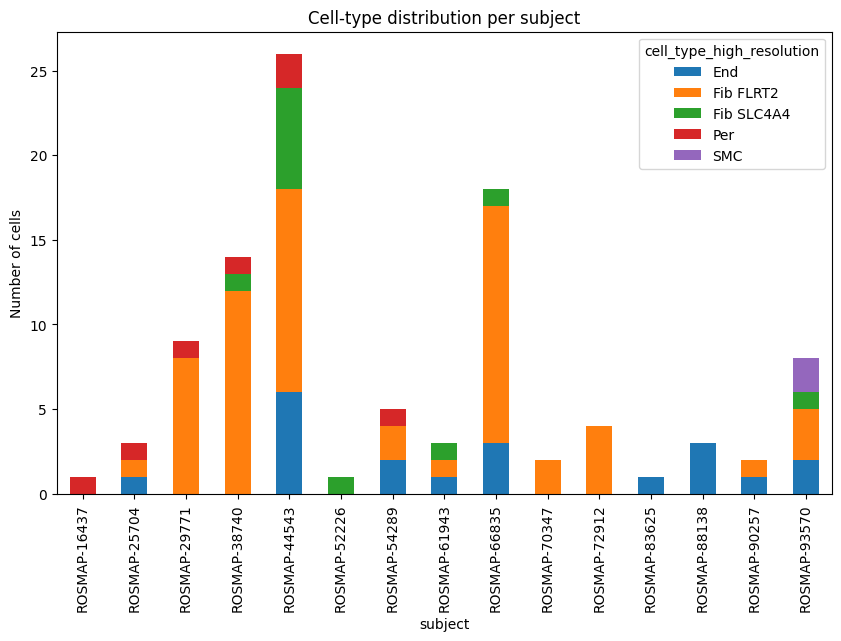

In [ ]:
# Visualization of Cell-types per patient, NOTE: count may be incorrect, order in data? 
ct_table = pd.crosstab(
    adata.obs["subject"][:100],
    adata.obs["cell_type_high_resolution"][:100]
)

ct_table.plot(kind="bar", stacked=True, figsize=(10,6))
plt.ylabel("Number of cells")
plt.title("Cell-type distribution per subject")
plt.show()

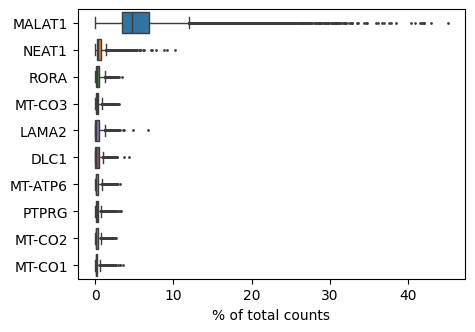

In [28]:
sc.pl.highest_expr_genes(adata, n_top=10)

In [5]:
# Sparsity Check
print(f"Sparse AnnData: {adata.n_obs} n_obs x {adata.n_vars} n_vars")
sparsity = 1 - adata.X.nnz / (adata.n_obs * adata.n_vars)
print(f"Sparsity: {sparsity:.2%}")

Sparse AnnData: 17974 n_obs x 33538 n_vars
Sparsity: 95.31%


In [6]:
# BACKED MODE
def read_in_backed(path):
    adata_backed = sc.read_h5ad(path, backed="r")   

    assert adata_backed.isbacked, "Should be in backed mode"
    
    print(f"Backed mode: {adata_backed.isbacked}")
    return adata_backed

# adata_backed = read_in_backed(path=vasc_path)
## NOTE: Close adata_backed when done!!
# adata_backed.file.close()

In [18]:
# Layers
adata.layers["raw"] = adata.X.copy()
#adata.layers["log1p"] = 
print(f"Available layers: {list(adata.layers.keys())}")


Available layers: ['logcounts', 'raw']


In [14]:
# Annloader 
loader = AnnLoader(adatas=adata, batch_size=32, shuffle=True)

# Verify loader properties
assert isinstance(loader, torch.utils.data.DataLoader), "Annloader is a DataLoader"
assert len(loader) == int(np.ceil(adata.n_obs / 32)), "Correct number of batches"

# Get first batch
batch = next(iter(loader))

# Check batch structure
assert hasattr(batch, "X"), "Batch should have attribute X"
assert hasattr(batch, "obs"), "-::- obs"
assert hasattr(batch, "obsm"), "-::- obsm"
assert batch.X.shape[0] == 32, "Batch size should be 32"

print(f"Number of batches: {len(loader)}")
print(f"Batch X shape: {batch.X.shape}")
print(f"Batch X type: {type(batch.X)}")
print(f"Batch obs keys: {batch.obs.keys()}")


Number of batches: 562
Batch X shape: torch.Size([32, 33538])
Batch X type: <class 'torch.Tensor'>
Batch obs keys: ['cell_type_high_resolution', 'subject', 'ident']


In [17]:
subjects = adata.obs["subject"].unique()

adata.obs


,cell_type_high_resolution,subject,ident
GACTACAAGGCTCTTA-1-0,Fib SLC4A4,ROSMAP-52226,Fib SLC4A4
ACTGAGTTCACTTATC-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
CACAAACGTAAGGGAA-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
CGGTTAAAGGCTCAGA-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
TACCTTACATTAACCG-2-0,Fib FLRT2,ROSMAP-72912,Fib FLRT2
...,...,...,...
CATTCCGAGCGACCCT-16-14,Per,ROSMAP-37074,Per
CGAAGGACAACGAGGT-16-14,Per,ROSMAP-37074,Per
CTAGACAAGCCACCGT-16-14,End,ROSMAP-37074,End
TTACGTTAGTAAACAC-16-14,End,ROSMAP-37074,End
